# 🔍 M2F2-Det: Deepfake Detection con tu propia foto

Este notebook permite ejecutar el modelo **M2F2-Det** (CVPR 2025 Oral) usando GPU de Google Colab desde VS Code.

**Dos modos disponibles:**
- **Stage 1** — Detección binaria rápida (Real / Fake + confianza)
- **Stage 3** — Detección + explicación generada por LLM (requiere ~16 GB VRAM)

> ⚠️ Asegúrate de conectarte a un runtime con **GPU (T4 o superior)** desde la extensión de Colab en VS Code.

## 1. Setup: Clonar repositorio e instalar dependencias

In [1]:
# Verificar que hay GPU disponible
import torch
if not torch.cuda.is_available():
    raise RuntimeError("❌ No se detectó GPU. Ve a Runtime → Change runtime type → GPU")
print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ GPU detectada: Tesla T4
   VRAM: 15.6 GB


In [2]:
# Clonar el repositorio (se omite si ya existe)
import os, re

REPO_DIR = "/content/M2F2_Det"
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/CHELSEA234/M2F2_Det.git {REPO_DIR}
    print("✅ Repositorio clonado.")
else:
    print("✅ Repositorio ya existe, omitiendo clone.")
os.chdir(REPO_DIR)
print(f"📂 Directorio de trabajo: {os.getcwd()}")

# ══════════════════════════════════════════════════════════════════════════════
# Parchear builder.py (cuantización compatible)
# ══════════════════════════════════════════════════════════════════════════════
builder_file = os.path.join(REPO_DIR, "llava/model/builder.py")
!git -C {REPO_DIR} checkout -- llava/model/builder.py

with open(builder_file, "r") as f:
    bsrc = f.read()

bsrc = bsrc.replace("low_cpu_mem_usage=False,", "low_cpu_mem_usage=True,")
bsrc = bsrc.replace(
    "        if device_map != 'auto':\n"
    "            vision_tower.to(device=device_map, dtype=torch.float16)\n",
    "        if device_map != 'auto' and not load_8bit and not load_4bit:\n"
    "            vision_tower.to(device=device_map, dtype=torch.float16)\n",
)
bsrc = bsrc.replace(
    "            bnb_4bit_quant_type='nf4'\n"
    "        )",
    "            bnb_4bit_quant_type='nf4',\n"
    "            llm_int8_skip_modules=['deepfake_encoder', 'deepfake_projector', 'lm_head', 'mm_projector']\n"
    "        )",
)
with open(builder_file, "w") as f:
    f.write(bsrc)
print("🔧 builder.py parcheado (skip_modules incluye deepfake_projector).")

# ══════════════════════════════════════════════════════════════════════════════
# Parchear llava_llama.py — SOLO map_location (el fix de self.device se hace
# en runtime, no a nivel de archivo, porque el bytecode cacheado lo ignora)
# ══════════════════════════════════════════════════════════════════════════════
llama_file = os.path.join(REPO_DIR, "llava/model/language_model/llava_llama.py")
!git -C {REPO_DIR} checkout -- llava/model/language_model/llava_llama.py

with open(llama_file, "r") as f:
    lsrc = f.read()
lsrc = lsrc.replace(
    "        ckpt = torch.load(model_path)\n",
    "        ckpt = torch.load(model_path, map_location='cpu')\n",
)
with open(llama_file, "w") as f:
    f.write(lsrc)
print("🔧 llava_llama.py parcheado: map_location='cpu'.")

# ══════════════════════════════════════════════════════════════════════════════
# Parchear model.py — flash_attn fallback
# ══════════════════════════════════════════════════════════════════════════════
model_file = os.path.join(REPO_DIR, "sequence/models/M2F2_Det/models/model.py")
!git -C {REPO_DIR} checkout -- sequence/models/M2F2_Det/models/model.py

with open(model_file, "r") as f:
    src = f.read()
src = src.replace(
    "from flash_attn.modules.mha import MHA",
    "try:\n"
    "    from flash_attn.modules.mha import MHA\n"
    "except ImportError:\n"
    "    import torch.nn as _nn\n"
    "    class MHA(_nn.Module):\n"
    '        """Fallback: nn.MultiheadAttention cuando flash_attn no está instalado."""\n'
    "        def __init__(self, embed_dim, num_heads, dropout=0.0, causal=False, **kw):\n"
    "            super().__init__()\n"
    "            self._mha = _nn.MultiheadAttention(\n"
    "                embed_dim, num_heads, dropout=dropout, batch_first=True)\n"
    "        def forward(self, x, **kw):\n"
    "            out, _ = self._mha(x, x, x)\n"
    "            return out.to(x.dtype)"
)
with open(model_file, "w") as f:
    f.write(src)
print("🔧 model.py parcheado: flash_attn fallback.")

✅ Repositorio ya existe, omitiendo clone.
📂 Directorio de trabajo: /content/M2F2_Det
🔧 builder.py parcheado (skip_modules incluye deepfake_projector).
🔧 llava_llama.py parcheado: map_location='cpu'.
🔧 model.py parcheado: flash_attn fallback.


In [3]:
# Instalar dependencias principales
# transformers 4.37.0 + tokenizers 0.15.1 son compatibles con llava
!pip install -q \
    torch torchvision \
    transformers==4.37.0 \
    tokenizers==0.15.1 \
    sentencepiece==0.1.99 \
    accelerate>=0.21.0 \
    peft>=0.10.0 \
    bitsandbytes>=0.43.1 \
    einops>=0.6.1 \
    einops-exts==0.0.4 \
    timm==0.4.12 \
    shortuuid \
    scikit-learn>=1.2.2 \
    pillow \
    requests \
    safetensors \
    huggingface_hub \
    gdown

# Instalar el paquete llava del repo
# --no-deps evita que sobreescriba las versiones que acabamos de fijar
!pip install -q --no-deps -e .

print("\n✅ Dependencias instaladas correctamente.")
print("ℹ️  El warning de sentence-transformers puede ignorarse (no se usa en este notebook).")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llava (pyproject.toml) ... done

✅ Dependencias instaladas correctamente.
ℹ️  El warning de sentence-transformers puede ignorarse (no se usa en este notebook).


In [4]:
# Configurar PYTHONPATH
import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + ":" + os.environ.get("PYTHONPATH", "")
print("✅ PYTHONPATH configurado.")

✅ PYTHONPATH configurado.


## 2. Descargar pesos del modelo

Se descargan automáticamente:
- **Vision tower** (CLIP encoder de LLaVA) → `utils/weights/vision_tower.pth`
- **Stage 1 weights** (detector binario) → `checkpoints/stage_1/current_model_180.pth`
- **Stage 3 weights** (modelo completo M2F2-Det con LLM) → `checkpoints/llava-v1.5-7b-M2F2-Det/`

In [5]:
import gdown

# --- Vision Tower weights ---
vision_tower_path = os.path.join(REPO_DIR, "utils/weights/vision_tower.pth")
os.makedirs(os.path.dirname(vision_tower_path), exist_ok=True)

if not os.path.exists(vision_tower_path):
    print("⬇️  Descargando vision_tower.pth (~1.7 GB)...")
    gdown.download(
        "https://drive.google.com/uc?id=19oEpKB96xJVSrwkLV0ewje-W2dfBAR58",
        vision_tower_path, quiet=False
    )
    print("✅ vision_tower.pth descargado.")
else:
    print("✅ vision_tower.pth ya existe.")

# --- Stage 1 detector weights ---
stage1_weights_path = os.path.join(REPO_DIR, "checkpoints/stage_1/current_model_180.pth")
os.makedirs(os.path.dirname(stage1_weights_path), exist_ok=True)

if not os.path.exists(stage1_weights_path):
    print("⬇️  Descargando current_model_180.pth (~400 MB)...")
    gdown.download(
        "https://drive.google.com/uc?id=1X1ZUZkCwqg9mrsqoOS0EoO3v5WABNBAw",
        stage1_weights_path, quiet=False
    )
    print("✅ Stage 1 weights descargados.")
else:
    print("✅ Stage 1 weights ya existen.")

# --- Deepfake encoder weights (densenet121) needed by Stage 3 ---
# Fuente: https://drive.google.com/drive/folders/1H0KcBQDu9-L0DMz0d66z1rabIy3FpGIH
densenet_weights_path = os.path.join(REPO_DIR, "utils/weights/M2F2_Det_densenet121.pth")

if not os.path.exists(densenet_weights_path):
    print("⬇️  Descargando M2F2_Det_densenet121.pth (~1.6 GB) desde Google Drive...")
    import tempfile, glob, shutil as _shutil
    tmp_dir = tempfile.mkdtemp()
    gdown.download_folder(
        "https://drive.google.com/drive/folders/1H0KcBQDu9-L0DMz0d66z1rabIy3FpGIH",
        output=tmp_dir,
        quiet=False,
        remaining_ok=True,
    )
    pth_files = glob.glob(os.path.join(tmp_dir, "**", "M2F2_Det_densenet121.pth"), recursive=True)
    if pth_files:
        _shutil.move(pth_files[0], densenet_weights_path)
        print("✅ M2F2_Det_densenet121.pth descargado.")
    else:
        print("⚠️  No se encontró M2F2_Det_densenet121.pth en la descarga. "
              "Descárgalo manualmente desde https://drive.google.com/drive/folders/1H0KcBQDu9-L0DMz0d66z1rabIy3FpGIH "
              f"y colócalo en: {densenet_weights_path}")
else:
    print("✅ M2F2_Det_densenet121.pth ya existe.")


✅ vision_tower.pth ya existe.
✅ Stage 1 weights ya existen.
✅ M2F2_Det_densenet121.pth ya existe.


In [6]:
# --- Stage 3 weights (modelo completo con LLM desde Hugging Face) ---
# Solo necesario si quieres la explicación textual (Stage 3)

stage3_model_path = os.path.join(REPO_DIR, "checkpoints/llava-v1.5-7b-M2F2-Det")

if not os.path.exists(os.path.join(stage3_model_path, "config.json")):
    print("⬇️  Descargando M2F2-Det completo desde HuggingFace (~14 GB)...")
    print("   Esto puede tardar varios minutos...")
    !git lfs install
    !git clone https://huggingface.co/CHELSEA234/llava-v1.5-7b-M2F2-Det {stage3_model_path}
    print("✅ Modelo M2F2-Det completo descargado.")
else:
    print("✅ Modelo M2F2-Det completo ya existe.")

✅ Modelo M2F2-Det completo ya existe.


## 3. Subir tu imagen

Sube una foto de una cara (recortada preferiblemente). El modelo funciona mejor con caras frontales centradas.

Mounted at /content/drive

🖼️  Imagen cargada: Captura de pantalla 2026-03-03 115312.png
   Tamaño: 302x393


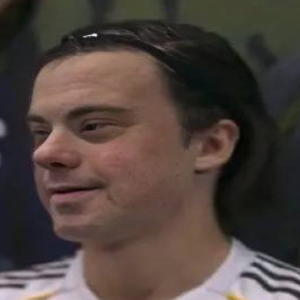

In [7]:
from IPython.display import display
from PIL import Image
import os, shutil

# ─────────────────────────────────────────────────────────────
# OPCIÓN A: Sube la imagen a Google Drive y pon aquí la ruta
#           (recomendado desde VS Code, donde files.upload() no funciona)
#
#   1. Abre https://drive.google.com en el navegador
#   2. Sube tu imagen (ej: mi_cara.jpg)
#   3. Monta Drive con la celda de abajo y pon el nombre del archivo

IMAGE_FILENAME = "Captura de pantalla 2026-03-03 115312.png"   # ← CAMBIA ESTO al nombre de tu archivo

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Buscar el archivo en Drive (raíz de My Drive)
drive_path = f"/content/drive/MyDrive/ML2/test_fotos/{IMAGE_FILENAME}"

if not os.path.exists(drive_path):
    raise FileNotFoundError(
        f"❌ No se encontró '{IMAGE_FILENAME}' en Google Drive (My Drive).\n"
        f"   Sube el archivo a https://drive.google.com y vuelve a ejecutar."
    )

IMAGE_PATH = os.path.join(REPO_DIR, IMAGE_FILENAME)
shutil.copy(drive_path, IMAGE_PATH)

# ─────────────────────────────────────────────────────────────
# OPCIÓN B (alternativa): descarga una imagen desde URL
#
# import urllib.request
# IMAGE_URL = "https://..."   # ← pon aquí la URL de tu imagen
# IMAGE_FILENAME = "test_image.jpg"
# IMAGE_PATH = os.path.join(REPO_DIR, IMAGE_FILENAME)
# urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)
# ─────────────────────────────────────────────────────────────

# Mostrar la imagen
print(f"\n🖼️  Imagen cargada: {IMAGE_FILENAME}")
img = Image.open(IMAGE_PATH).convert('RGB')
print(f"   Tamaño: {img.size[0]}x{img.size[1]}")
display(img.resize((300, 300)))

## 4. Stage 1 — Detección binaria (Real / Fake)

Usa solo el detector binario basado en EfficientNet + CLIP. Rápido y ligero.

In [8]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from sequence.models.M2F2_Det.models.model import M2F2Det

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construir modelo
print("[1/4] Construyendo modelo M2F2Det...")
model_s1 = M2F2Det(
    clip_text_encoder_name="openai/clip-vit-large-patch14-336",
    clip_vision_encoder_name="openai/clip-vit-large-patch14-336",
    deepfake_encoder_name='efficientnet_b4',
    hidden_size=1792,
)

# Cargar vision tower
print("[2/4] Cargando CLIP vision tower...")
llava_vision_tower = torch.load(vision_tower_path, map_location=device, weights_only=True)
vision_tower_dict = {k.replace("vision_tower.", ""): v for k, v in llava_vision_tower.items()}
if model_s1.clip_vision_encoder is not None:
    model_s1.clip_vision_encoder.model.load_state_dict(vision_tower_dict, strict=True)
    print("   ✅ CLIP vision tower cargado.")

# Envolver en DataParallel (requerido por el checkpoint)
model_s1 = torch.nn.DataParallel(model_s1)
model_s1 = model_s1.to(device)

# Cargar pesos del detector
# weights_only=False necesario porque el checkpoint incluye scheduler/optimizador
print("[3/4] Cargando pesos del detector...")
checkpoint = torch.load(stage1_weights_path, map_location=device, weights_only=False)
model_s1.load_state_dict(checkpoint['model_state_dict'], strict=True)
print("   ✅ Pesos del detector cargados.")

model_s1.eval()

# Preprocesar imagen
print(f"[4/4] Procesando imagen: {IMAGE_FILENAME}")
image = Image.open(IMAGE_PATH).convert('RGB')
image = image.resize((224, 224), Image.Resampling.BILINEAR)
image_np = np.array(image).astype(np.float32) / 255.0
image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).to(device)

# Inferencia
with torch.no_grad():
    output = model_s1(image_tensor, return_dict=True)
    pred = output['pred']
    probs = F.softmax(pred, dim=-1)

real_prob = probs[0, 0].item()
fake_prob = probs[0, 1].item()
is_real = real_prob > fake_prob

print("\n" + "=" * 50)
print("       M2F2-Det RESULTADO (Stage 1)")
print("=" * 50)
print(f"  Imagen:     {IMAGE_FILENAME}")
print(f"  Predicción: {'✅ REAL' if is_real else '❌ FAKE'}")
print(f"  Confianza:  {max(real_prob, fake_prob) * 100:.1f}%")
print(f"  P(Real):    {real_prob * 100:.1f}%")
print(f"  P(Fake):    {fake_prob * 100:.1f}%")
print("=" * 50)

# Liberar memoria
del model_s1, checkpoint
torch.cuda.empty_cache()

[1/4] Construyendo modelo M2F2Det...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Freezing CLIP vision encoder.
[2/4] Cargando CLIP vision tower...
   ✅ CLIP vision tower cargado.
[3/4] Cargando pesos del detector...
   ✅ Pesos del detector cargados.
[4/4] Procesando imagen: Captura de pantalla 2026-03-03 115312.png

       M2F2-Det RESULTADO (Stage 1)
  Imagen:     Captura de pantalla 2026-03-03 115312.png
  Predicción: ❌ FAKE
  Confianza:  71.9%
  P(Real):    28.1%
  P(Fake):    71.9%


## 5. Stage 3 — Detección + Explicación con LLM

Usa el modelo completo M2F2-Det (LLaVA-7B + detector deepfake).

> ⚠️ Requiere ~14 GB de VRAM. Funciona en T4 (16 GB) o superior.  
> Si tienes problemas de memoria, usa `load_4bit=True` en la celda siguiente.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# ESTRATEGIA: hacemos TODOS los fixes a nivel de objetos Python en memoria.
#
# FIX 1: PreTrainedModel.to() → no-op para modelos cuantizados
# FIX 2: nn.Embedding.forward() → auto-move input al device del weight
# FIX 3: Override de la propiedad 'device' en la clase del modelo
# FIX 4: Convertir deepfake_encoder bfloat16 → float16 (T4 compat)
# FIX 5: Dequantizar deepfake_projector y mm_projector si bnb los cuantizó
# FIX 6: Monkey-patch encode_deepfake_tokens y encode_images_multimodal_features
#         para NUNCA depender de .weight.dtype (que puede ser uint8 si bnb cuantizó)
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import sys, importlib

# ── Flush módulos llava para reimportar limpio ──
for mod in list(sys.modules):
    if 'llava' in mod:
        del sys.modules[mod]
importlib.invalidate_caches()

# ── FIX 1: PreTrainedModel.to (idempotente) ──
import transformers.modeling_utils as _tmu
if not getattr(_tmu.PreTrainedModel.to, '_m2f2_patched', False):
    _orig_pt_to = _tmu.PreTrainedModel.to
    def _safe_pretrained_to(self, *args, **kwargs):
        if getattr(self, 'quantization_method', None) is not None:
            return self
        return _orig_pt_to(self, *args, **kwargs)
    _safe_pretrained_to._m2f2_patched = True
    _tmu.PreTrainedModel.to = _safe_pretrained_to
    print("🔧 FIX 1: PreTrainedModel.to parcheado")

# ── FIX 2: nn.Embedding.forward auto-move (idempotente) ──
if not getattr(torch.nn.Embedding.forward, '_m2f2_patched', False):
    _orig_emb_fwd = torch.nn.Embedding.forward
    def _safe_emb_fwd(self, input):
        if input.device != self.weight.device:
            input = input.to(self.weight.device)
        return _orig_emb_fwd(self, input)
    _safe_emb_fwd._m2f2_patched = True
    torch.nn.Embedding.forward = _safe_emb_fwd
    print("🔧 FIX 2: nn.Embedding.forward parcheado (auto-move device)")

# ══════════════════════════════════════════════════════════════════════════════
# Importar y cargar modelo
# ══════════════════════════════════════════════════════════════════════════════
import os, json
from PIL import Image
from llava.constants import IMAGE_TOKEN_INDEX, DEEPFAKE_TOKEN_INDEX
from llava.model.builder import load_deepfake_model
from llava.mm_utils import tokenizer_hybrid_token, get_model_name_from_path

LOAD_4BIT = True
LOAD_8BIT = False

print("⏳ Cargando modelo M2F2-Det completo (puede tardar 1-2 min)...")
model_name = get_model_name_from_path(stage3_model_path)
tokenizer, model_s3, image_processor, context_len = load_deepfake_model(
    stage3_model_path,
    model_base=None,
    model_name=model_name,
    load_8bit=LOAD_8BIT,
    load_4bit=LOAD_4BIT,
    device="cuda"
)
model_s3.eval()

# ── FIX 3: Override device property en la clase del modelo ──
if LOAD_4BIT or LOAD_8BIT:
    type(model_s3).device = property(lambda self: self.get_model().embed_tokens.weight.device)
    print(f"🔧 FIX 3: device property → {model_s3.device}")
else:
    model_s3 = model_s3.to('cuda')

# ── Cargar deepfake encoder ──
correct_deepfake_path = os.path.join(REPO_DIR, "utils/weights/M2F2_Det_densenet121.pth")
if not os.path.exists(correct_deepfake_path):
    raise FileNotFoundError(f"❌ No se encontró '{correct_deepfake_path}'")
model_s3.config.deepfake_model_path = correct_deepfake_path

def _patched_load(self, model_path, verbose=True):
    ckpt = torch.load(model_path, map_location='cpu')
    state_dict = {k: ckpt[k].to(v.dtype) for k, v in self.deepfake_encoder.state_dict().items() if k in ckpt}
    mk, uk = self.deepfake_encoder.load_state_dict(state_dict, strict=False)
    if verbose:
        print(f'Load deepfake encoder | Missing: {mk} | Unexpected: {uk}')
model_s3.__class__.load_deepfake_encoder = _patched_load
model_s3.load_deepfake_encoder(correct_deepfake_path)

# ══════════════════════════════════════════════════════════════════════════════
# FIX 4: bfloat16 → float16 para T4 en deepfake_encoder (M2F2Det)
# ══════════════════════════════════════════════════════════════════════════════
_TARGET_DTYPE = torch.float16
de = model_s3.deepfake_encoder

for name, param in de.named_parameters():
    if param.is_floating_point() and param.dtype != _TARGET_DTYPE:
        param.data = param.data.to(_TARGET_DTYPE)
for name, buf in de.named_buffers():
    if buf.is_floating_point() and buf.dtype != _TARGET_DTYPE:
        buf.data = buf.data.to(_TARGET_DTYPE)

de.deepfake_dtype = _TARGET_DTYPE
de.vision_dtype = _TARGET_DTYPE
de.text_dtype = _TARGET_DTYPE
de.clip_text_encoder.dtype = _TARGET_DTYPE
de.cached_clip_text_features = None
print("🔧 FIX 4: deepfake_encoder → float16 + atributos dtype corregidos")

# ══════════════════════════════════════════════════════════════════════════════
# FIX 5: Dequantizar deepfake_projector y mm_projector si bnb los cuantizó
#
#   bitsandbytes reemplaza nn.Linear con Linear4bit, cuyo .weight.dtype = uint8.
#   Código como `out.to(self.deepfake_projector[0].weight.dtype)` castea a uint8,
#   y GELU no soporta uint8 → "GeluCUDAKernelImpl not implemented for Byte".
#
#   Solución: detectar y reemplazar Linear4bit con nn.Linear float16 dequantizado.
# ══════════════════════════════════════════════════════════════════════════════
try:
    import bitsandbytes as bnb
    _BNB_LINEAR_TYPES = (bnb.nn.Linear4bit, bnb.nn.Linear8bitLt)
except ImportError:
    _BNB_LINEAR_TYPES = ()

def _dequantize_sequential(seq_module, module_name, target_dtype=torch.float16):
    """Reemplaza Linear4bit/Linear8bit en un nn.Sequential con nn.Linear float16."""
    if not isinstance(seq_module, nn.Sequential):
        return seq_module
    has_quantized = any(isinstance(m, _BNB_LINEAR_TYPES) for m in seq_module)
    if not has_quantized:
        print(f"   {module_name}: ya está en float (no fue cuantizado) ✓")
        return seq_module

    new_children = []
    for i, child in enumerate(seq_module):
        if isinstance(child, _BNB_LINEAR_TYPES):
            # Dequantizar peso
            if isinstance(child, bnb.nn.Linear4bit) and hasattr(child.weight, 'quant_state') and child.weight.quant_state is not None:
                w = bnb.functional.dequantize_4bit(child.weight.data, child.weight.quant_state)
            else:
                w = child.weight.data
            target_device = w.device if w.device.type == 'cuda' else torch.device('cuda')
            w = w.to(dtype=target_dtype, device=target_device)
            has_bias = child.bias is not None
            new_linear = nn.Linear(child.in_features, child.out_features, bias=has_bias,
                                   device=target_device, dtype=target_dtype)
            new_linear.weight.data.copy_(w)
            if has_bias:
                new_linear.bias.data.copy_(child.bias.data.to(dtype=target_dtype, device=target_device))
            new_children.append(new_linear)
            print(f"   {module_name}[{i}]: Linear4bit → nn.Linear float16 ✓")
        else:
            new_children.append(child)
    return nn.Sequential(*new_children)

# Dequantizar deepfake_projector
model_s3.deepfake_projector = _dequantize_sequential(
    model_s3.deepfake_projector, "deepfake_projector", _TARGET_DTYPE
)
# Asegurar que está en float16 (por si no fue cuantizado sino bf16)
model_s3.deepfake_projector = model_s3.deepfake_projector.to(dtype=_TARGET_DTYPE)

# Dequantizar mm_projector (el vision→text projector en LlavaLlamaModel)
model_s3.get_model().mm_projector = _dequantize_sequential(
    model_s3.get_model().mm_projector, "mm_projector", _TARGET_DTYPE
)
print("🔧 FIX 5: Projectors dequantizados/verificados")

# ══════════════════════════════════════════════════════════════════════════════
# FIX 6: Monkey-patch encode_deepfake_tokens y encode_images_multimodal_features
#   para NUNCA usar .weight.dtype (que puede ser uint8 con bnb)
#   → siempre usar float16 explícito
# ══════════════════════════════════════════════════════════════════════════════
def _safe_encode_deepfake_tokens(self, deepfake_inputs):
    """encode_deepfake_tokens con float16 forzado en vez de .weight.dtype"""
    out = self.deepfake_encoder(**deepfake_inputs).unsqueeze(1)   # [B, 1, 2]
    out = F.softmax(out, dim=-1)
    out = out.to(torch.float16)   # ← SIEMPRE float16, nunca .weight.dtype
    if self.deepfake_replicate:
        out = torch.repeat_interleave(out, 200, dim=1)
    out = self.deepfake_projector(out)
    return out

model_s3.__class__.encode_deepfake_tokens = _safe_encode_deepfake_tokens
print("🔧 FIX 6a: encode_deepfake_tokens → float16 forzado")

def _safe_encode_images_multimodal_features(self, images):
    """encode_images_multimodal_features con float16 forzado"""
    images = images.to(dtype=torch.float16)  # ← SIEMPRE float16
    visual_image_features = self.get_model().get_vision_tower()(images)
    visual_fp16 = visual_image_features.to(dtype=torch.float16)
    textual_image_features = self.get_model().mm_projector(visual_fp16)
    return visual_image_features, textual_image_features

model_s3.__class__.encode_images_multimodal_features = _safe_encode_images_multimodal_features
print("🔧 FIX 6b: encode_images_multimodal_features → float16 forzado")

# ══════════════════════════════════════════════════════════════════════════════
# FIX 7: Rotary embedding device mismatch
#   Con device_map='auto' (4-bit), LlamaRotaryEmbedding.cos_cached/sin_cached
#   son non-persistent buffers que se quedan en CPU. apply_rotary_pos_emb
#   hace cos[position_ids] donde position_ids está en CUDA → crash.
#   Solución: parchear apply_rotary_pos_emb para mover cos/sin al device correcto.
# ══════════════════════════════════════════════════════════════════════════════
import transformers.models.llama.modeling_llama as _llama_mod

if not getattr(_llama_mod, '_m2f2_rotary_patched', False):
    _orig_apply_rotary = _llama_mod.apply_rotary_pos_emb

    def _safe_apply_rotary_pos_emb(q, k, cos, sin, position_ids, unsqueeze_dim=1):
        target_device = q.device
        if cos.device != target_device:
            cos = cos.to(target_device)
        if sin.device != target_device:
            sin = sin.to(target_device)
        if position_ids.device != target_device:
            position_ids = position_ids.to(target_device)
        return _orig_apply_rotary(q, k, cos, sin, position_ids, unsqueeze_dim)

    _llama_mod.apply_rotary_pos_emb = _safe_apply_rotary_pos_emb
    _llama_mod._m2f2_rotary_patched = True
    print("🔧 FIX 7: apply_rotary_pos_emb parcheado (auto-move device)")

# ══════════════════════════════════════════════════════════════════════════════
# Verificación final
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n🔍 Verificación:")
print(f"   model_s3.device = {model_s3.device}")
print(f"   embed_tokens device = {model_s3.get_model().embed_tokens.weight.device}")
print(f"   deepfake_encoder dtype = {next(de.parameters()).dtype}")
print(f"   deepfake_projector[0] type = {type(model_s3.deepfake_projector[0]).__name__}, "
      f"weight.dtype = {model_s3.deepfake_projector[0].weight.dtype}")
print(f"   mm_projector[0] type = {type(model_s3.get_model().mm_projector[0]).__name__}, "
      f"weight.dtype = {model_s3.get_model().mm_projector[0].weight.dtype}")

# Sanity check: ningún projector debe tener uint8
for pname, proj in [("deepfake_projector", model_s3.deepfake_projector),
                    ("mm_projector", model_s3.get_model().mm_projector)]:
    for i, child in enumerate(proj):
        if hasattr(child, 'weight') and child.weight.dtype == torch.uint8:
            print(f"   ⚠️ {pname}[{i}] TODAVÍA tiene weight.dtype=uint8!")
        elif hasattr(child, 'weight'):
            pass  # OK

print("✅ Modelo cargado y parcheado correctamente.")

🔧 FIX 1: PreTrainedModel.to parcheado
🔧 FIX 2: nn.Embedding.forward parcheado (auto-move device)
⏳ Cargando modelo M2F2-Det completo (puede tardar 1-2 min)...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:623: UserWarning: for vision_model.embeddings.class_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:623: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:623: UserWarning: for vision_model.embeddings.posi

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

🔧 FIX 3: device property → cuda:0
Load deepfake encoder | Missing: [] | Unexpected: []
🔧 FIX 4: deepfake_encoder → float16 + atributos dtype corregidos
   deepfake_projector: ya está en float (no fue cuantizado) ✓
   mm_projector: ya está en float (no fue cuantizado) ✓
🔧 FIX 5: Projectors dequantizados/verificados
🔧 FIX 6a: encode_deepfake_tokens → float16 forzado
🔧 FIX 6b: encode_images_multimodal_features → float16 forzado
🔧 FIX 7: apply_rotary_pos_emb parcheado (auto-move device)

🔍 Verificación:
   model_s3.device = cuda:0
   embed_tokens device = cuda:0
   deepfake_encoder dtype = torch.float16
   deepfake_projector[0] type = Linear, weight.dtype = torch.float16
   mm_projector[0] type = Linear, weight.dtype = torch.float16
✅ Modelo cargado y parcheado correctamente.


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# FIX 7: Rotary embedding device mismatch
#   Con device_map='auto' (4-bit), LlamaRotaryEmbedding.cos_cached/sin_cached
#   son non-persistent buffers que se quedan en CPU. apply_rotary_pos_emb
#   hace cos[position_ids] donde position_ids está en CUDA → crash.
#   Solución: parchear apply_rotary_pos_emb para mover cos/sin al device correcto.
# ══════════════════════════════════════════════════════════════════════════════
import transformers.models.llama.modeling_llama as _llama_mod

if not getattr(_llama_mod, '_m2f2_rotary_patched', False):
    _orig_apply_rotary = _llama_mod.apply_rotary_pos_emb

    def _safe_apply_rotary_pos_emb(q, k, cos, sin, position_ids, unsqueeze_dim=1):
        target_device = q.device
        if cos.device != target_device:
            cos = cos.to(target_device)
        if sin.device != target_device:
            sin = sin.to(target_device)
        if position_ids.device != target_device:
            position_ids = position_ids.to(target_device)
        return _orig_apply_rotary(q, k, cos, sin, position_ids, unsqueeze_dim)

    _llama_mod.apply_rotary_pos_emb = _safe_apply_rotary_pos_emb
    _llama_mod._m2f2_rotary_patched = True
    print("🔧 FIX 7: apply_rotary_pos_emb parcheado (auto-move device)")
else:
    print("🔧 FIX 7: apply_rotary_pos_emb ya parcheado ✓")

# --- Detección (Real/Fake) ---
image = Image.open(IMAGE_PATH).convert('RGB')
image_size = image.size

# Prompt idéntico al usado en cli_DDVQA_det.py del repo original
prompt_det = (
    "Assistant: A chat between a curious human and an artificial intelligence assistant. "
    "The assistant gives helpful, detailed, and polite answers to the human's questions."
    "###Human: <image>\n <deepfake>\n Determine the authenticity. Is the image real or fake? ###Assistant:"
)

input_ids = tokenizer_hybrid_token(
    prompt_det, tokenizer, IMAGE_TOKEN_INDEX, DEEPFAKE_TOKEN_INDEX, return_tensors='pt'
).unsqueeze(0).to(model_s3.device)

print("🔍 Ejecutando detección...")
with torch.inference_mode():
    output = model_s3.generate(
        input_ids,
        images=[image],
        image_sizes=[image_size],
        deepfake_inputs=[image],
        do_sample=False,
        num_beams=1,
        max_new_tokens=512,
        use_cache=True,
        output_hidden_states=True,
        return_dict_in_generate=True
    )

output_text = tokenizer.decode(output['sequences'][0]).strip()

print("\n" + "=" * 60)
print("    M2F2-Det RESULTADO (Stage 3 - Detección)")
print("=" * 60)
print(f"  Imagen: {IMAGE_FILENAME}")
if "###Assistant:" in output_text:
    answer = output_text.split("###Assistant:")[-1].strip()
elif "Assistant:" in output_text:
    answer = output_text.split("Assistant:")[-1].strip()
else:
    answer = output_text
answer = answer.replace("</s>", "").replace("<s>", "").strip()
print(f"  {answer}")
print("=" * 60)

🔧 FIX 7: apply_rotary_pos_emb ya parcheado ✓
🔍 Ejecutando detección...

    M2F2-Det RESULTADO (Stage 3 - Detección)
  Imagen: Captura de pantalla 2026-03-03 115312.png
  The image is real.


In [11]:
# --- Explicación detallada ---
prompt_exp = (
    "Assistant: A chat between a curious human and an artificial intelligence assistant. "
    "The assistant gives helpful, detailed, and polite answers to the human's questions."
    "###Human: <image>\n <deepfake>\n Determine the authenticity and explain your reasoning "
    "in detail. What visual cues indicate whether this face is real or manipulated? ###Assistant:"
)

input_ids_exp = tokenizer_hybrid_token(
    prompt_exp, tokenizer, IMAGE_TOKEN_INDEX, DEEPFAKE_TOKEN_INDEX, return_tensors='pt'
).unsqueeze(0).to(model_s3.device)

print("🔍 Generando explicación detallada...")
with torch.inference_mode():
    output_exp = model_s3.generate(
        input_ids_exp,
        images=[image],
        image_sizes=[image_size],
        deepfake_inputs=[image],
        do_sample=False,
        num_beams=1,
        max_new_tokens=512,
        use_cache=True,
        output_hidden_states=True,
        return_dict_in_generate=True
    )

output_text_exp = tokenizer.decode(output_exp['sequences'][0]).strip()

print("\n" + "=" * 60)
print("    M2F2-Det RESULTADO (Stage 3 - Explicación)")
print("=" * 60)
print(f"  Imagen: {IMAGE_FILENAME}")
print(f"\n  Explicación del modelo:")
if "###Assistant:" in output_text_exp:
    answer_exp = output_text_exp.split("###Assistant:")[-1].strip()
elif "Assistant:" in output_text_exp:
    answer_exp = output_text_exp.split("Assistant:")[-1].strip()
else:
    answer_exp = output_text_exp
answer_exp = answer_exp.replace("</s>", "").replace("<s>", "").strip()
print(f"  {answer_exp}")
print("=" * 60)

🔍 Generando explicación detallada...

    M2F2-Det RESULTADO (Stage 3 - Explicación)
  Imagen: Captura de pantalla 2026-03-03 115312.png

  Explicación del modelo:
  The person has naturally straight nose and even skin, which are common features in manipulated media. The person has mismatched beard. The person has mismatched mustache. The person's face doesn't match the overall scene.


In [12]:
# Liberar memoria GPU
del model_s3
torch.cuda.empty_cache()
print("🧹 Memoria GPU liberada.")

🧹 Memoria GPU liberada.


## Notas

- **Stage 1** es rápido y ligero (~2 GB VRAM). Ideal para detección binaria.
- **Stage 3** usa LLaVA-7B completo (~14 GB VRAM). Si tienes problemas de memoria en T4, cambia `load_4bit=True`.
- El modelo funciona mejor con **caras recortadas y frontales**.
- Paper: [ArXiv 2503.20188](https://arxiv.org/abs/2503.20188) | Repo: [CHELSEA234/M2F2_Det](https://github.com/CHELSEA234/M2F2_Det)